In [5]:
import numpy as np
import matplotlib.pyplot as plt

import h5ify

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth

## compare to what I think is the truth

In [2]:
det = h5ify.load('../data/vt/mock/detectable.hdf5')

In [3]:
injs = h5ify.load('../data/vt/mock/all.hdf5')

In [4]:
import json
with open('./parameters/o4a-strong-maxl.json', 'r') as f:
    parameters = json.loads(f.read())

Text(0, 0.5, '$p(m_1)$')

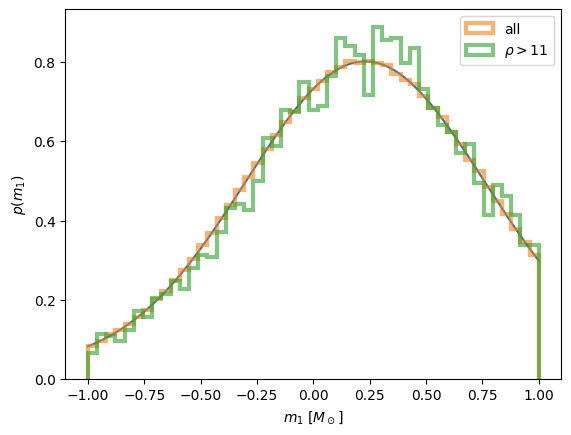

In [12]:
from models import marg_iso_gauss_spin_tilt

fig, ax = plt.subplots()

bins = np.linspace(-1, 1, 50)
cts = np.linspace(-1, 1, 500)

ax.plot(
    cts,
    marg_iso_gauss_spin_tilt(cts, parameters['xi_spin'], parameters['sigma_spin'], parameters['mu_spin'])
)

ax.hist(
    injs['cos_tilt_1'],
    histtype='step',
    bins=bins,
    density=True,
    linewidth=3,
    alpha=0.6,
    label='all'
)
ax.hist(
    det['cos_tilt_1'],
    histtype='step',
    bins=bins,#np.logspace(np.log10(3), np.log10(300), 100),
    density=True,
    linewidth=3,
    alpha=0.6,
    label=r'$\rho > 11$'
)
#ax.loglog()
#ax.set_ylim(1e-8, 1e0)
ax.legend()

ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel(r'$p(m_1)$')

Text(0, 0.5, '$p(m_1)$')

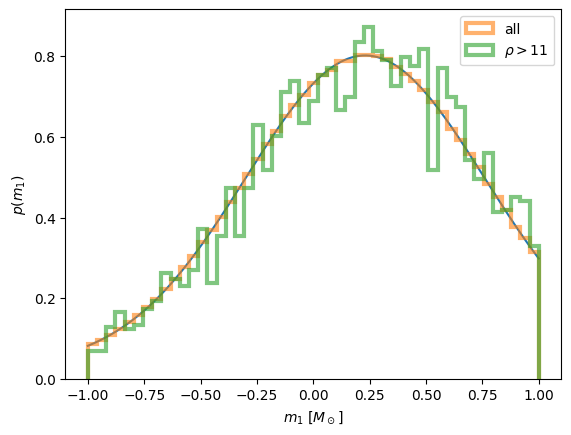

In [13]:
from models import marg_iso_gauss_spin_tilt

fig, ax = plt.subplots()

bins = np.linspace(-1, 1, 50)
cts = np.linspace(-1, 1, 500)

ax.plot(
    cts,
    marg_iso_gauss_spin_tilt(cts, parameters['xi_spin'], parameters['sigma_spin'], parameters['mu_spin'])
)

ax.hist(
    injs['cos_tilt_2'],
    histtype='step',
    bins=bins,
    density=True,
    linewidth=3,
    alpha=0.6,
    label='all'
)
ax.hist(
    det['cos_tilt_2'],
    histtype='step',
    bins=bins,#np.logspace(np.log10(3), np.log10(300), 100),
    density=True,
    linewidth=3,
    alpha=0.6,
    label=r'$\rho > 11$'
)
#ax.loglog()
#ax.set_ylim(1e-8, 1e0)
ax.legend()

ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel(r'$p(m_1)$')

In [6]:
test_m1s = jnp.linspace(3, 300, 2_000)
p_m1 = np.exp(BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    dict(mass_1=test_m1s),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mlow_1=parameters['mlow_1'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(
        parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
    ),
    mpp_1=parameters['mpp_1'],
    sigpp_1=parameters['sigpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_2=parameters['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
))

/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0, 0.5, '$p(m_1)$')

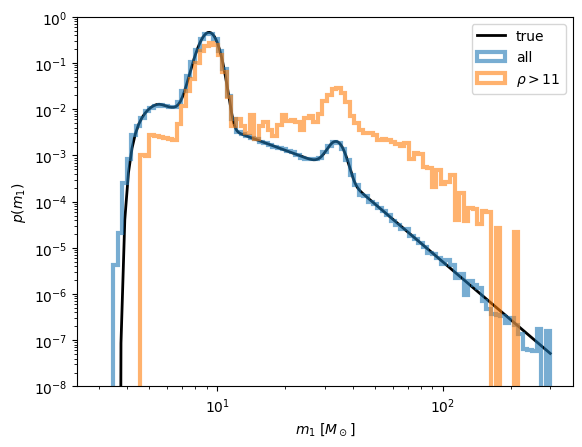

In [8]:
fig, ax = plt.subplots()
ax.plot(
    test_m1s,
    p_m1,
    color='black',
    linewidth=2,
    label='true'
)
ax.hist(
    injs['mass_1_source'],
    histtype='step',
    bins=np.logspace(np.log10(3), np.log10(300), 100),
    density=True,
    linewidth=3,
    alpha=0.6,
    label='all'
)
ax.hist(
    det['mass_1_source'],
    histtype='step',
    bins=np.logspace(np.log10(3), np.log10(300), 100),
    density=True,
    linewidth=3,
    alpha=0.6,
    label=r'$\rho > 11$'
)
ax.loglog()
ax.set_ylim(1e-8, 1e0)
ax.legend()

ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel(r'$p(m_1)$')

In [30]:
from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

m1s = jnp.linspace(3, 300, 500)
qs = jnp.linspace(0.1, 1, 500)
mm, qq = jnp.meshgrid(m1s, qs, indexing='ij')

p_m1 = jnp.exp(BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    dict(mass_1=mm),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mlow_1=parameters['mlow_1'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(
        parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
    ),
    mpp_1=parameters['mpp_1'],
    sigpp_1=parameters['sigpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_2=parameters['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
))

log_p_q_given_m1 = PowerlawPlusPeak_MassRatio(
    dict(mass_1=mm, mass_ratio=qq),
    slope=parameters['beta'],
    minimum=parameters['mlow_1'],
    delta_m=parameters['delta_m_1']
)
p_q_given_m1 = jnp.exp(log_p_q_given_m1)

p_m1q = p_m1 * p_q_given_m1
p_q = jnp.trapezoid(p_m1q, m1s, axis=0)

Text(0, 0.5, '$p(q)$')

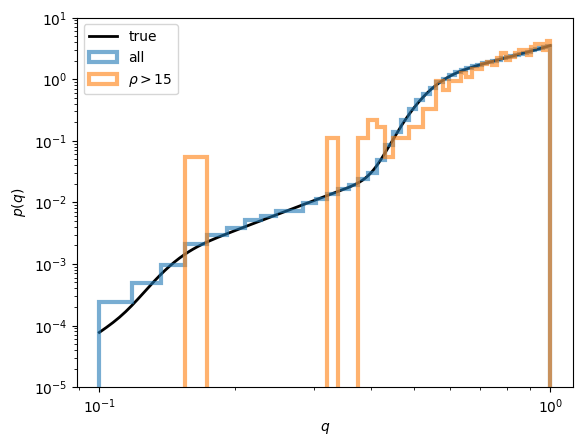

In [33]:
fig, ax = plt.subplots()
ax.plot(
    qs,
    p_q,
    color='black',
    linewidth=2,
    label='true'
)
ax.hist(
    injs['mass_ratio'],
    histtype='step',
    bins=np.linspace(0.1, 1, 50),
    density=True,
    linewidth=3,
    alpha=0.6,
    label='all'
)
ax.hist(
    det['mass_ratio'],
    histtype='step',
    bins=np.linspace(0.1, 1, 50),
    density=True,
    linewidth=3,
    alpha=0.6,
    label=r'$\rho > 15$'
)
ax.loglog()
ax.set_ylim(1e-5, 1e1)
ax.legend()

ax.set_xlabel(r'$q$')
ax.set_ylabel(r'$p(q)$')

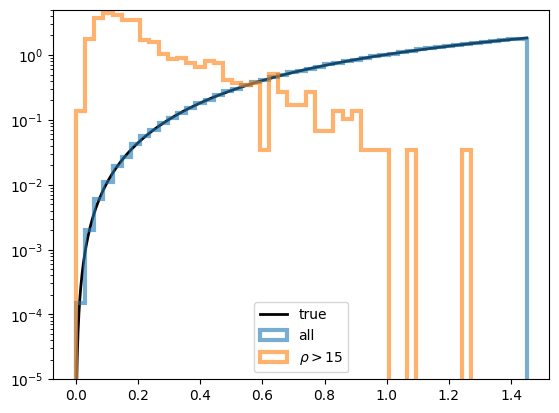

In [52]:
from models import log_powerlaw_redshift

z_max = parameters['z_max']
zs = np.linspace(1e-5, z_max, 1000)
pz = np.exp(log_powerlaw_redshift(
    dict(redshift=zs),
    parameters
))

fig, ax = plt.subplots()
ax.plot(
    zs,
    pz,
    color='black',
    linewidth=2,
    label='true'
)

ax.hist(
    injs['redshift'],
    histtype='step',
    bins=np.linspace(0, 1.45, 50),
    density=True,
    linewidth=3,
    alpha=0.6,
    label='all'
)
ax.hist(
    det['redshift'],
    histtype='step',
    bins=np.linspace(0, 1.45, 50),
    density=True,
    linewidth=3,
    alpha=0.6,
    label=r'$\rho > 15$'
)

ax.set_yscale('log')
ax.set_ylim(1e-5, 5e0)
ax.legend();

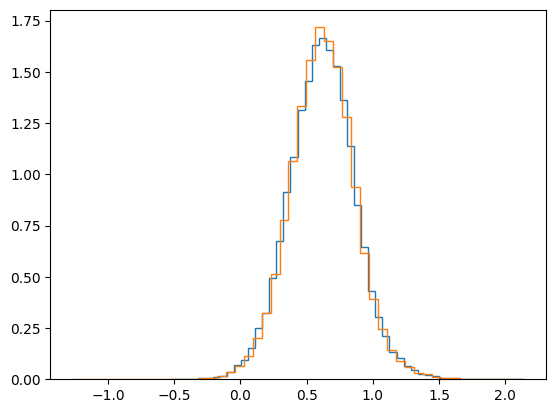

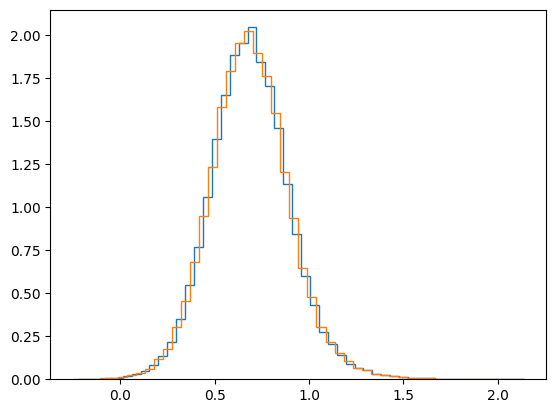

In [58]:
mask = injs['network_matched_filter_snr'] > 0

bins = 50

fig, ax = plt.subplots()
ax.hist(
    np.log10(injs['injection_network_optimal_snr'][mask]),
    bins=bins,
    histtype='step',
    density=True
)
ax.hist(
    np.log10(injs['network_optimal_snr'][mask]),
    bins=bins,
    histtype='step',
    density=True
);

fig, ax = plt.subplots()
ax.hist(
    np.log10(injs['injection_network_matched_filter_snr'][mask]),
    bins=bins,
    histtype='step',
    density=True
)
ax.hist(
    np.log10(injs['network_matched_filter_snr'][mask]),
    bins=bins,
    histtype='step',
    density=True
);

## test our vt by doing some pop inference w/ deltas

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
import matplotlib.pyplot as plt

import h5ify

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

In [2]:
from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

from models import truncnorm
from models import log_powerlaw_redshift
from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth
from models import iso_gauss_spin_tilt

def model(dataset, parameters):
    if 'lam_2' not in parameters.keys():
        if 'lam_0' in parameters.keys() and 'lam_1' in parameters.keys():
            parameters['lam_2'] = 1 - parameters['lam_0'] - parameters['lam_1']

    log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
        dataset,
        alpha_1=parameters['alpha_1'],
        alpha_2=parameters['alpha_2'],
        mlow_1=parameters['mlow_1'],
        break_mass=parameters['break_mass'],
        delta_m_1=parameters['delta_m_1'],
        lam_fractions=(
            parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
        ),
        mpp_1=parameters['mpp_1'],
        sigpp_1=parameters['sigpp_1'],
        mpp_2=parameters['mpp_2'],
        sigpp_2=parameters['sigpp_2'],
        mmax=300.0,
        gaussian_mass_maximum=100.0
    )
    p_m1 = jnp.exp(log_p_m1)

    log_p_q_given_m1 = PowerlawPlusPeak_MassRatio(
        dataset,
        slope=parameters['beta'],
        minimum=parameters['mlow_1'],
        delta_m=parameters['delta_m_1']
    )
    p_q_given_m1 = jnp.exp(log_p_q_given_m1)

    log_pl_z = log_powerlaw_redshift(dataset, parameters)
    p_z = jnp.exp(log_pl_z)

    p_a1 = truncnorm(
        dataset['a_1'],
        parameters['mu_chi'],
        parameters['sigma_chi'],
        high=1,
        low=0
    )
    p_a2 = truncnorm(
        dataset['a_2'],
        parameters['mu_chi'],
        parameters['sigma_chi'],
        high=1,
        low=0
    )

    p_cos_tilts = iso_gauss_spin_tilt(
        dataset,
        parameters['xi_spin'],
        parameters['sigma_spin'],
        parameters['mu_spin']
    )

    return p_m1 * p_q_given_m1 * p_z * p_a1 * p_a2 * p_cos_tilts

/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
posteriors = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/vt/mock/detectable.hdf5')
posteriors['prior'] = np.tile(1, len(posteriors['log_prior']))

for k in list(posteriors.keys()):
    if k not in ['network_matched_filter_snr', 'mass_1_source', 'mass_ratio', 'redshift', 'a_1', 'a_2', 'cos_tilt_1', 'cos_tilt_2', 'prior']:
        posteriors.pop(k)

mask = posteriors['network_matched_filter_snr'] > 15

for k in list(posteriors.keys()):
    posteriors[k] = posteriors[k][mask]

idxs = np.random.choice(
    len(posteriors['prior']),
    size=100
)

posteriors = {k : v[idxs] for k, v in posteriors.items()}
posteriors = {k : jnp.array(v[:, None]) for k, v in posteriors.items()}
posteriors['mass_1'] = posteriors.pop('mass_1_source')

In [4]:
idxs

array([ 948, 1670, 1288,  745,  987, 1523,  742, 1023,  472,  927, 1442,
       1478,  325, 1665, 1404,  266, 1219, 1306, 1466, 1249,  165,  682,
        842,  647,  941, 1707,  944, 1352,  336, 1530, 1162, 1269,  580,
        444, 1467, 1671,  610, 1402, 1362, 1080, 1539, 1053,  718,  940,
        715,   58,  440,  686, 1194,  807,  160, 1564, 1273, 1561,  609,
       1197, 1177,  997,  881, 1379, 1487,  777,  588, 1283,  380, 1014,
       1199,  864,   55,  424, 1132,  126,   92, 1038, 1612,  859,   69,
        530,  634, 1333,  541,  819,   44, 1285,  410, 1614,   32, 1109,
       1568, 1133,  384,    7, 1432,  696,  625,  846, 1151, 1419, 1024,
        362])

In [5]:
injections = h5ify.load('/home/noah.wolfe/projects/tilts-and-kicks/data/vt/fly/detectable.hdf5')
injections['prior'] = np.exp(injections.pop('log_prior'))

for k in list(injections.keys()):
    if k not in ['network_matched_filter_snr', 'mass_1_source', 'mass_ratio', 'redshift', 'a_1', 'a_2', 'cos_tilt_1', 'cos_tilt_2', 'prior', 'total_generated']:
        injections.pop(k)

mask = injections['network_matched_filter_snr'] > 15
for k in list(injections.keys()):
    if k != 'total_generated':
        injections[k] = injections[k][mask]

injections = {k : jnp.array(v) for k, v in injections.items()}
injections['mass_1'] = injections.pop('mass_1_source')

In [6]:
import bilby
from bilby.core.prior import PriorDict, ConditionalPriorDict

prior = './priors/lvk.prior'
#prior = PriorDict(prior)
#for k in ['mu_spin', 'sigma_spin', 'xi_spin']:
#    prior.pop(k)
#
prior = ConditionalPriorDict(prior)

In [7]:
from bilby_util import LikelihoodWrapper
likelihood = LikelihoodWrapper(posteriors, injections, model, taper=lambda _: 0)
likelihood.parameters.update(prior.sample())
print('log like ratio: ', likelihood.log_likelihood_ratio())

log like ratio:  -inf


In [9]:
outdir = '../data/runs/deltas-iso-gauss-snr15-nobs100'

In [8]:
bilby.core.utils.random.seed(1)
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=prior,
    outdir=outdir,
    nlive=100,
    sample='acceptance-walk',
    naccept=5
)

18:06 bilby INFO    : Running for label 'label', output will be saved to '../data/runs/deltas-iso-gauss-snr15-nobs100'
18:06 bilby INFO    : Analysis priors:
18:06 bilby INFO    : alpha_1=Uniform(minimum=-4, maximum=12, name=None, latex_label=None, unit=None, boundary=None)
18:06 bilby INFO    : alpha_2=Uniform(minimum=-4, maximum=12, name=None, latex_label=None, unit=None, boundary=None)
18:06 bilby INFO    : break_mass=Uniform(minimum=20, maximum=50, name=None, latex_label=None, unit=None, boundary=None)
18:06 bilby INFO    : mpp_1=Uniform(minimum=5, maximum=20, name=None, latex_label=None, unit=None, boundary=None)
18:06 bilby INFO    : sigpp_1=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
18:06 bilby INFO    : mpp_2=Uniform(minimum=25, maximum=60, name=None, latex_label=None, unit=None, boundary=None)
18:06 bilby INFO    : sigpp_2=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
18:06 bilby INFO    : delta

3925it [08:43,  7.82it/s, bound:122 nc: 22 ncall:7.7e+04 eff:5.1% logz-ratio=-76.28+/-0.55 dlogz:0.1>0.1]   

18:15 bilby INFO    : Written checkpoint file ../data/runs/deltas-iso-gauss-snr15-nobs100/label_resume.pickle


3925it [08:52,  7.36it/s, bound:122 nc:  1 ncall:7.7e+04 eff:5.3% logz-ratio=-76.24+/-0.57 dlogz:0.000993>0.1]

18:15 bilby INFO    : Rejection sampling nested samples to obtain 724 posterior samples
18:15 bilby INFO    : Sampling time: 0:08:52.989147


18:15 bilby INFO    : Summary of results:
nsamples: 724
ln_noise_evidence:    nan
ln_evidence:    nan +/-  0.635
ln_bayes_factor: -76.240 +/-  0.635



In [10]:
import json
with open('./parameters/o4a-strong-maxl.json', 'r') as f:
    parameters = json.loads(f.read())

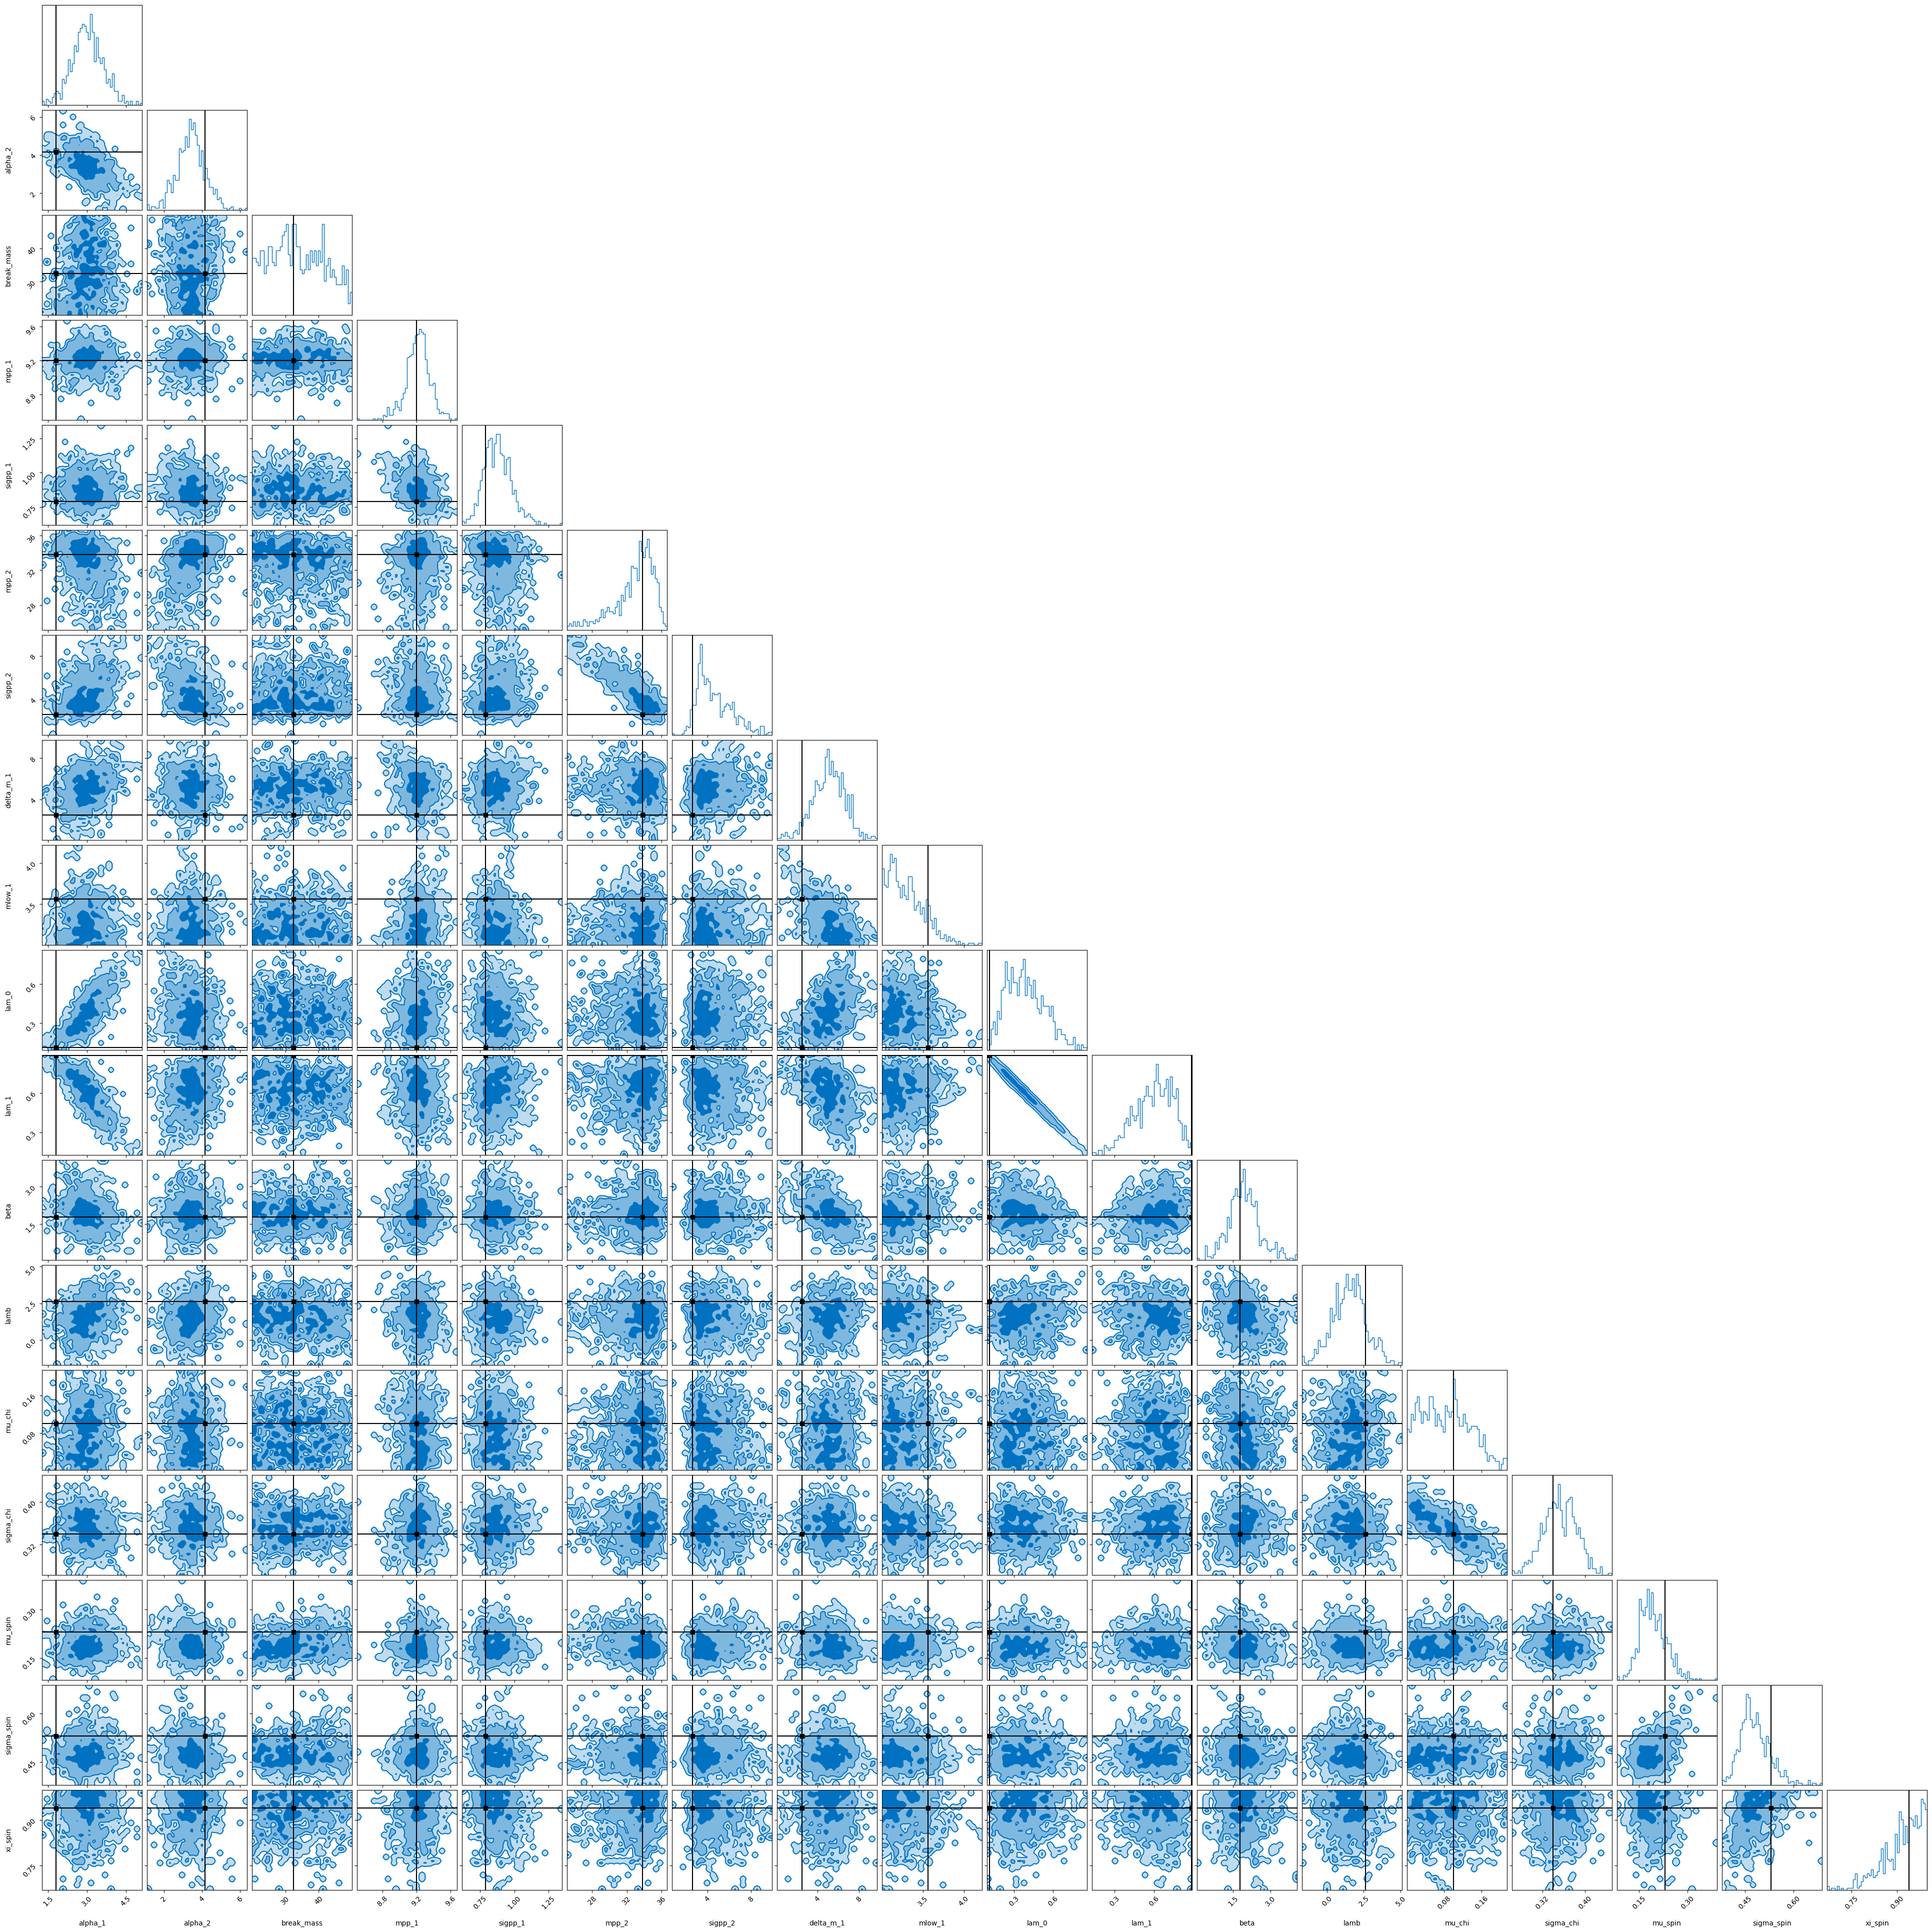

In [11]:
from util import plot_corner

plot_corner(
    {k : v for k, v in result.posterior.items() if k not in ['log_prior', 'log_likelihood']},
    truths=[
        parameters[k]
        for k in result.posterior.keys()
        if k not in ['log_prior', 'log_likelihood']
    ],
    fname=f'{outdir}/corner.png'
);